In [9]:
import random
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt
from pam.core import Household, Person
from pam.plot.plans import plot_household
from pandas import DataFrame

from caveat.data.utils import trace_to_pam

In [49]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    # "Compositional": Path("~/Data/actvae/compositional"),
    # "MDCEV": Path("~/Data/actvae/mdcev"),
    "ActVAE": Path("~/Data/actvae/L6"),
    "CP": Path("~/Data/actvae/cp"),
    "Aux0_1": Path("~/Data/actvae/aux0_1"),
    "Aux0_001": Path("~/Data/actvae/aux0_001"),
    "CPAux0_1": Path("~/Data/actvae/cp_aux0_1"),
    "CPAux0_001": Path("~/Data/actvae/cp_aux0_001"),
    # "Qwen": Path("~/Data/actvae/qwen2.5-0.5B"),
    # "Gemma": Path("~/Data/actvae/gemma4-2B"),
    # "QwenFT": Path("~/Data/actvae/qwen2.5-0.5B_ft"),
}

# find data
target_schedules = pd.read_csv("~/Data/foundata/out/nts/2023/activities.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    "~/Data/foundata/out/nts/2023/attributes_binned.csv"
)


def get_latest_version(path: Path):
    versions = [
        d
        for d in path.iterdir()
        if d.is_dir() and d.name.startswith("version_")
    ]
    if not versions:
        return path
    latest_version = max(versions, key=lambda d: int(d.name.split("_")[1]))
    print(f"Found versions {versions}, using latest version {latest_version}")
    return path / latest_version


def load_attributes(path: Path, default=None):
    path = path.expanduser().resolve()
    # check path exists
    if not path.exists():
        raise FileNotFoundError(f"Path {path} does not exist.")
    path = get_latest_version(path)
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def load_schedules(path: Path):
    path = path.expanduser().resolve()
    # check path exists
    if not path.exists():
        raise FileNotFoundError(f"Path {path} does not exist.")
    path = get_latest_version(path)
    if (path / "synthetic_schedules.csv").exists():
        print(f"Loading synthetic schedules from {path}")
        return pd.read_csv(path / "synthetic_schedules.csv")
    if (path / "schedules.csv").exists():
        print(f"Loading synthetic schedules from {path}")
        return pd.read_csv(path / "schedules.csv")
    if (path / "activities.csv").exists():
        print(f"Loading synthetic schedules from {path}")
        return pd.read_csv(path / "activities.csv")
    print(f"Failed to find schedules at {path}")
    return None


def split_on(schedules, attributes, by="employment"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }


schedules = {n: load_schedules(p) for n, p in batch_paths.items()}
attributes = {
    n: load_attributes(p, default=target_attributes)
    for n, p in batch_paths.items()
}

/tmp/ipykernel_1667262/3514195304.py:32: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  target_attributes = pd.read_csv(


Found versions [PosixPath('/home/fred/Data/actvae/L6/version_0')], using latest version /home/fred/Data/actvae/L6/version_0
Loading synthetic schedules from /home/fred/Data/actvae/L6/version_0
Found versions [PosixPath('/home/fred/Data/actvae/cp/version_0')], using latest version /home/fred/Data/actvae/cp/version_0
Loading synthetic schedules from /home/fred/Data/actvae/cp/version_0
Found versions [PosixPath('/home/fred/Data/actvae/aux0_1/version_0')], using latest version /home/fred/Data/actvae/aux0_1/version_0
Loading synthetic schedules from /home/fred/Data/actvae/aux0_1/version_0
Found versions [PosixPath('/home/fred/Data/actvae/aux0_001/version_0')], using latest version /home/fred/Data/actvae/aux0_001/version_0
Loading synthetic schedules from /home/fred/Data/actvae/aux0_001/version_0
Found versions [PosixPath('/home/fred/Data/actvae/cp_aux0_1/version_0')], using latest version /home/fred/Data/actvae/cp_aux0_1/version_0
Loading synthetic schedules from /home/fred/Data/actvae/cp_a

In [50]:
target_attributes.head()

,hid,pid,age,hh_size,hh_income,sex,dwelling,ownership,vehicles,disability,...,source,year,month,day,hh_zone,weight,access_egress_distance,max_temp_c,rain,avg_speed
0,nts2023000001,nts202300000101,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,monday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
1,nts2023000001,nts202300000102,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,tuesday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
2,nts2023000001,nts202300000103,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,wednesday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
3,nts2023000001,nts202300000104,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,thursday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
4,nts2023000001,nts202300000105,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,friday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663


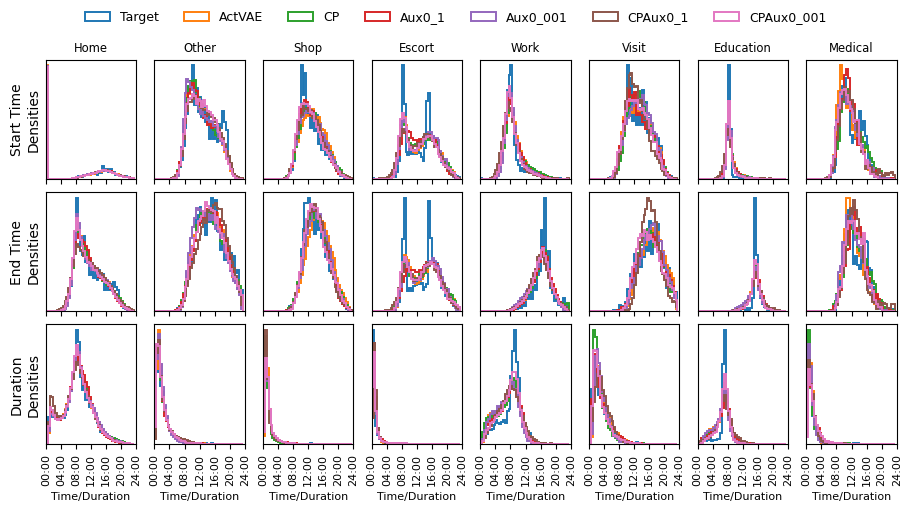

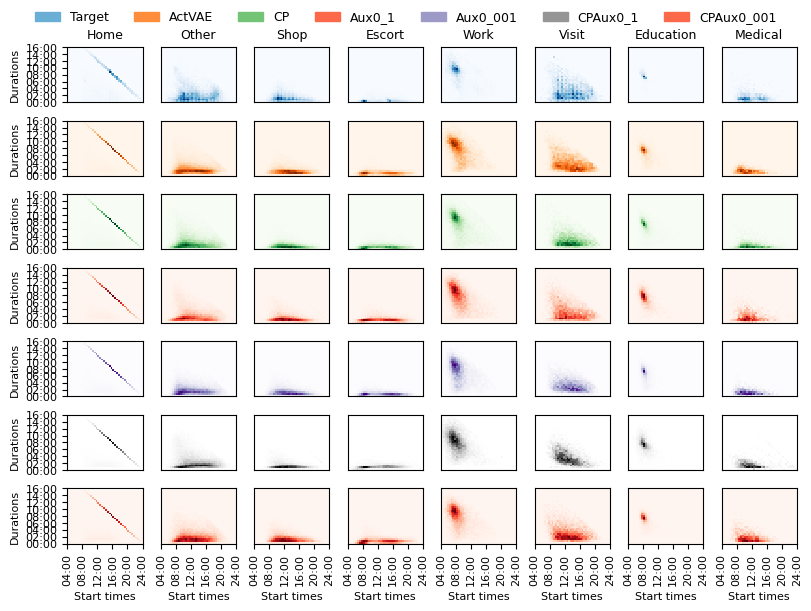

In [51]:
from acteval.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)

fig = times_distributions_plot(
    target_schedules, schedules, observed_title="Target", figsize=(9, 5)
)

fig = joint_time_distributions_plot(
    target_schedules,
    schedules,
    figsize=(8, 6),
    observed_title="Target",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)

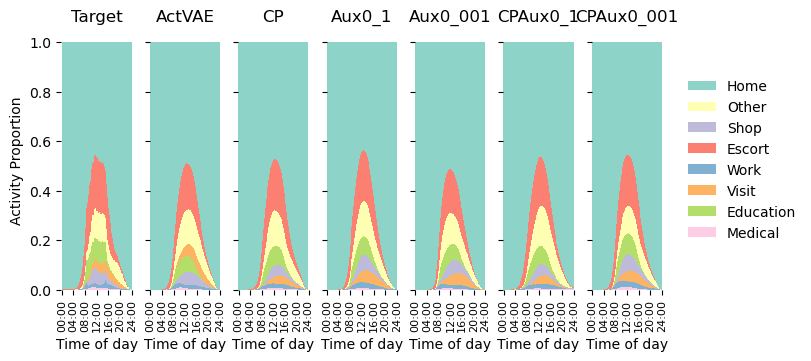

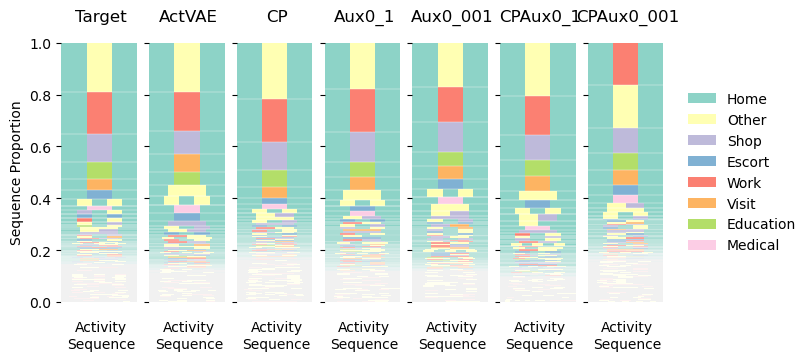

In [52]:
from acteval.describe.frequency import frequency_plots
from acteval.describe.transitions import sequence_prob_plot

fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)

In [53]:
schedules.keys()

dict_keys(['ActVAE', 'CP', 'Aux0_1', 'Aux0_001', 'CPAux0_1', 'CPAux0_001'])

In [54]:
def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):
    schedules = schedules.copy()
    cmap = {
        "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
        "other": (1.0, 1.0, 0.7019607843137254),
        "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
        "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
        "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
        "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
        "education": (
            0.7019607843137254,
            0.8705882352941177,
            0.4117647058823529,
        ),
        "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
        "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    }
    cmap = {n.title(): c for n, c in cmap.items()}

    hh = Household("")
    pids = schedules.pid
    selected = random.sample(list(pids), 8)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

In [55]:
# for name, schedules in schedules.items():
#     print(f"Plotting schedules for {name}")
#     plot_schedules(schedules)

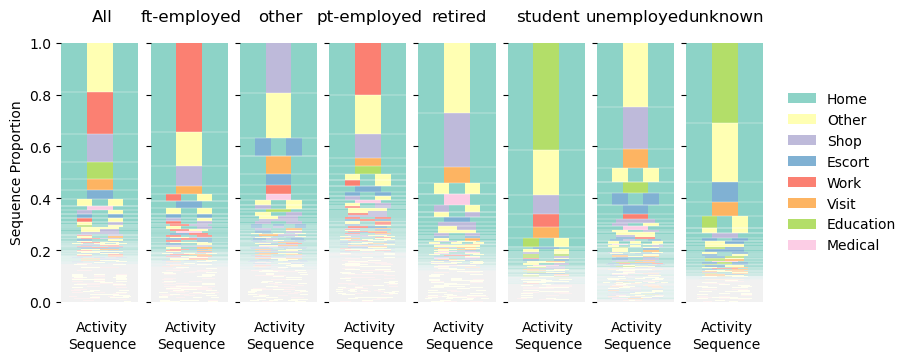

In [57]:
splits = split_on(target_schedules, target_attributes)
fig = sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

Plotting schedules for ActVAE
Plotting schedules for CP
Plotting schedules for Aux0_1
Plotting schedules for Aux0_001
Plotting schedules for CPAux0_1
Plotting schedules for CPAux0_001


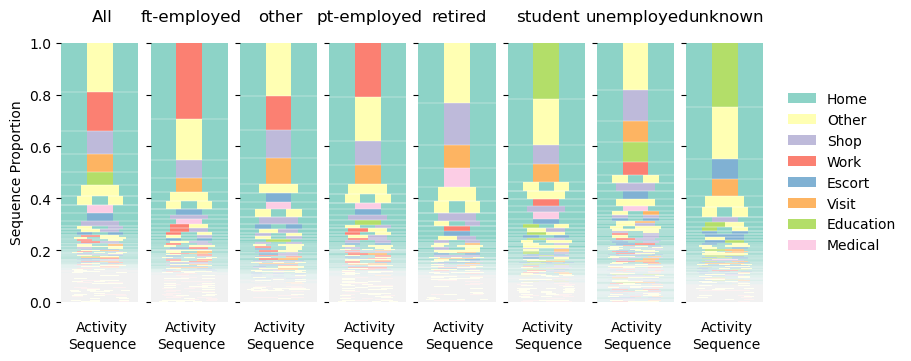

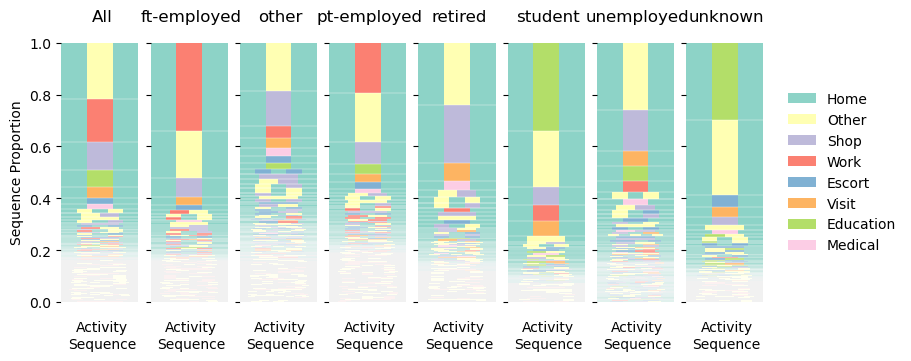

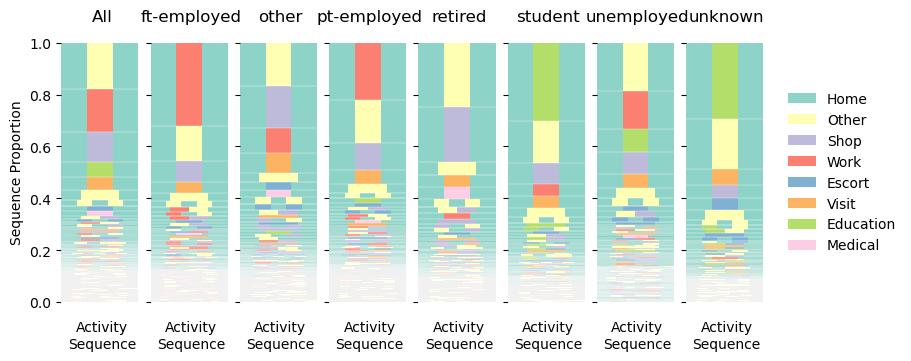

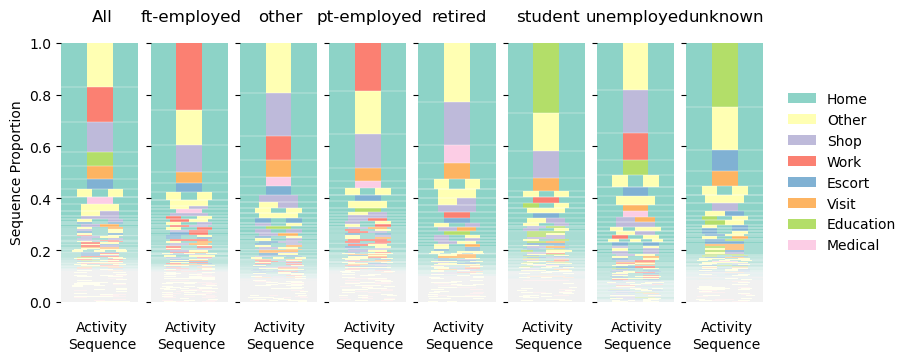

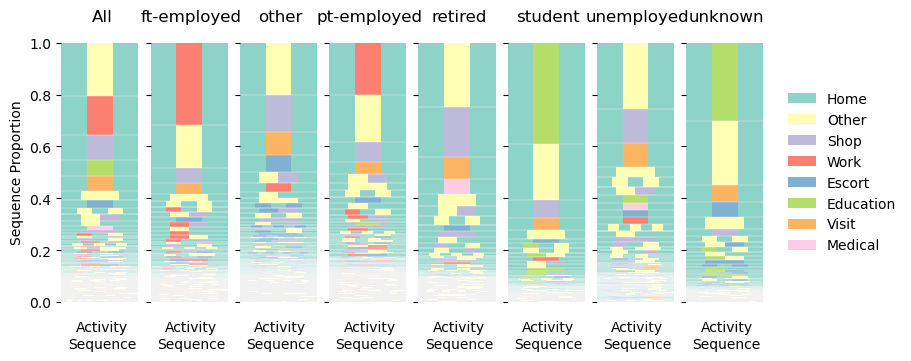

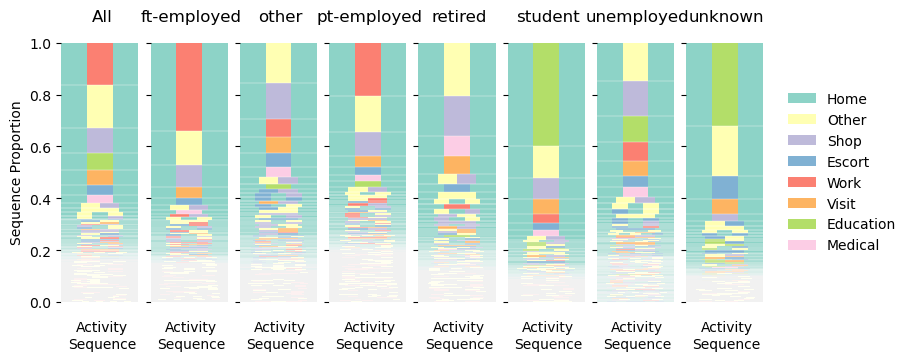

In [58]:
for k, scheds in schedules.items():
    print(f"Plotting schedules for {k}")
    splits = split_on(scheds, attributes[k])
    fig = sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

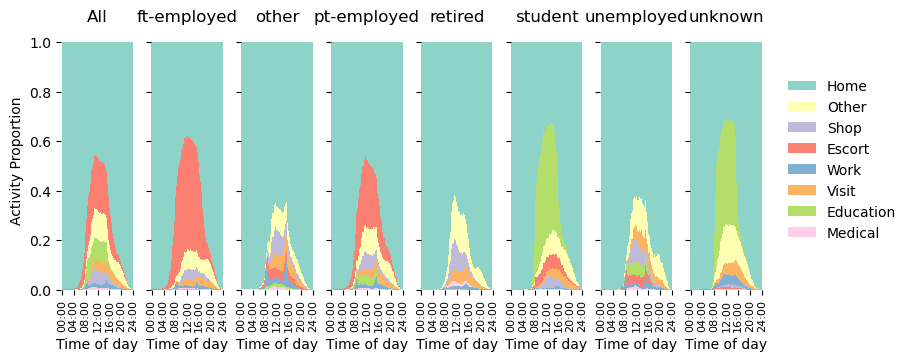

In [59]:
splits = split_on(target_schedules, target_attributes)
fig = frequency_plots(
    target_schedules, splits, observed_title="All", color=cmap, figsize=(9, 3.5)
)

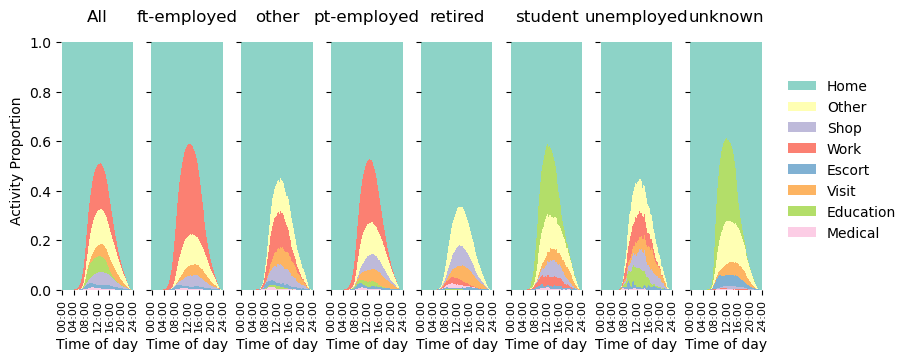

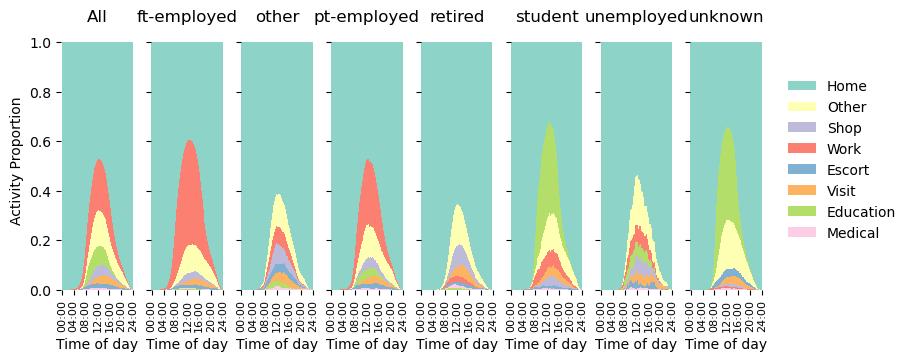

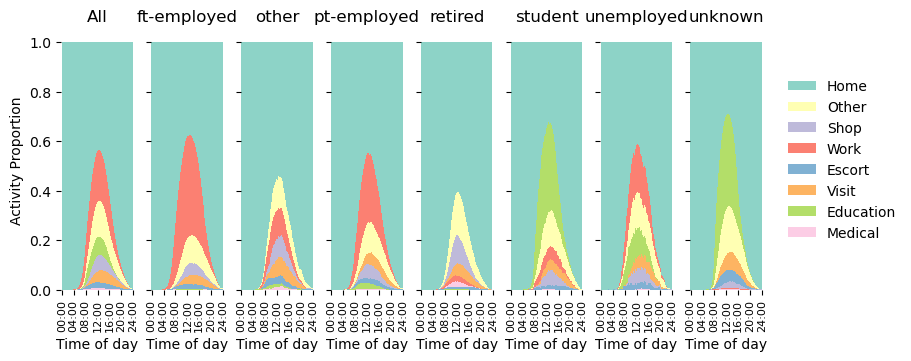

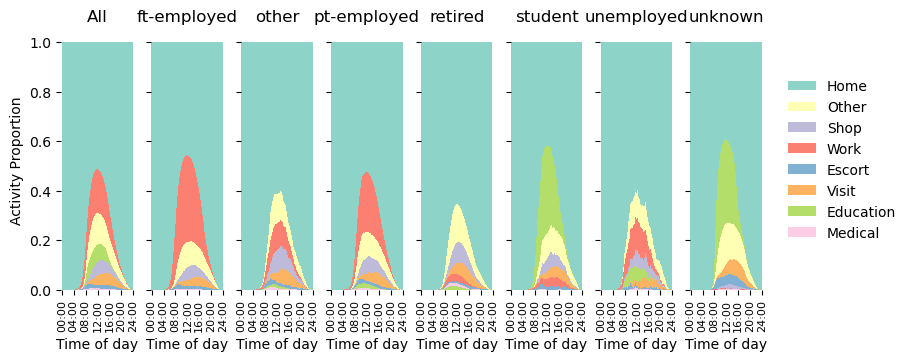

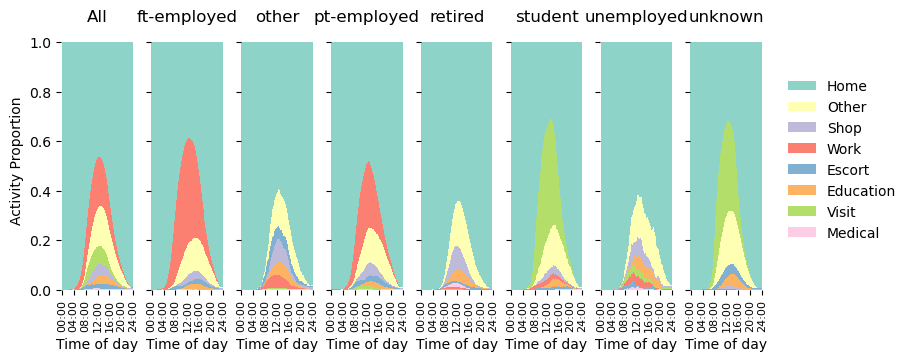

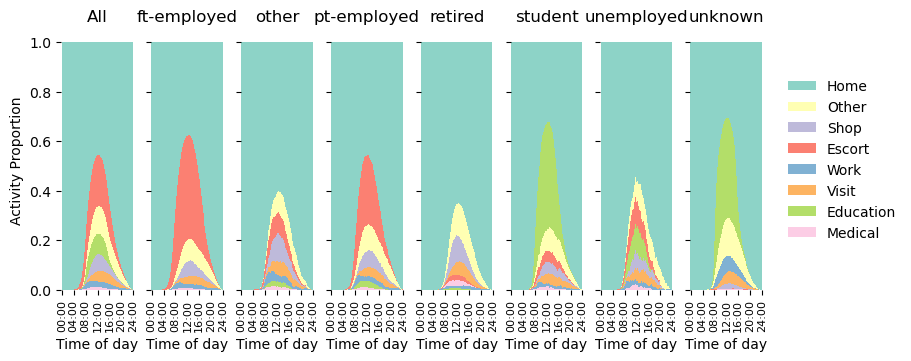

In [60]:
for k, scheds in schedules.items():
    splits = split_on(scheds, attributes[k])
    fig = frequency_plots(
        scheds, splits, observed_title="All", color=cmap, figsize=(9, 3.5)
    )

In [61]:
target_attributes.employment.value_counts()

employment
ft-employed    21878
retired        14997
unknown         9277
pt-employed     6685
other           2069
student         1342
unemployed       486
Name: count, dtype: int64

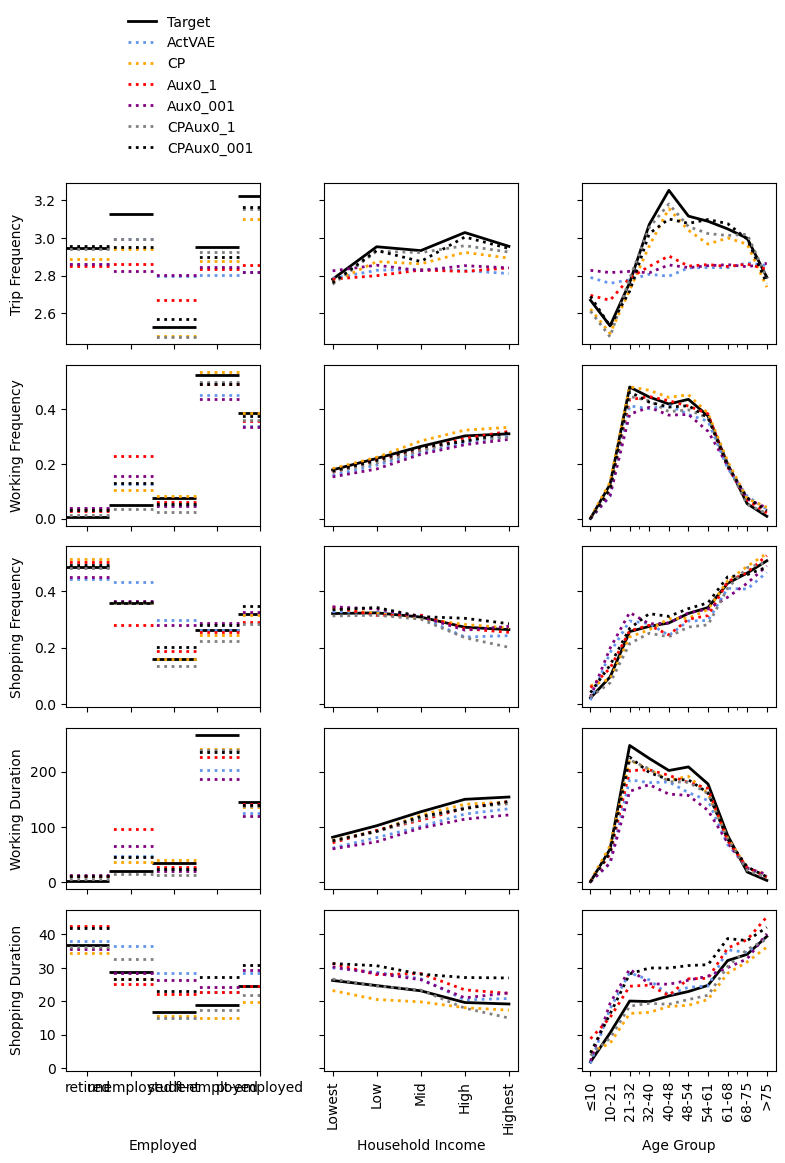

In [62]:
def duration(schedules, act="work"):
    if "duration" not in schedules.columns:
        durations = schedules.end - schedules.start
    else:
        durations = schedules.duration
    n = schedules.pid.nunique()
    return durations[schedules.act == act].sum() / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(schedules.loc[schedules.act == act]) / n


def plot_conditionals(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    WORK_STATUS = "employment"
    INCOME = "hh_income"
    AGE = "age"

    work_order = [
        "retired",
        "unemployed",
        "student",
        "ft-employed",
        "pt-employed",
    ]

    age_order = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    ages = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    incomes = ["≤22316", "22316-32118", "32118-44107", "44107-68887", ">68887"]
    colours = [
        "black",
        "cornflowerblue",
        "orange",
        "red",
        "purple",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", ":", ":", ":", ":", ":", ":", ":", ":", ":", ":"]

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[0][0]
    # change to bar plot
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[1][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Working Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[2][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Shopping Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[3][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_ylabel("Working Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[4][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_xlim(-0.5, 2.5)

    ax.set_ylabel("Shopping Duration")
    ax.set_xlabel("Employed")
    ax.set_xticks(list(range(len(work_order))), work_order, rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Household Income")
    ax.set_xticks(
        [0, 1, 2, 3, 4],
        ["Lowest", "Low", "Mid", "High", "Highest"],
        rotation=90,
    )

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Age Group")
    ax.set_xticks(range(len(ages)), ages, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.25, 1),
    )

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals(schedules, attributes, target_schedules, target_attributes)